In [1]:
# ---Data Manipulation---
import numpy as np
import pandas as pd

# ---Data Visualization---
import seaborn as sns
import matplotlib.pyplot as plt

# ---Maths---
import math
import scipy as stats

tips_df = sns.load_dataset('tips')
tips_df


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<Axes: xlabel='tip', ylabel='Count'>

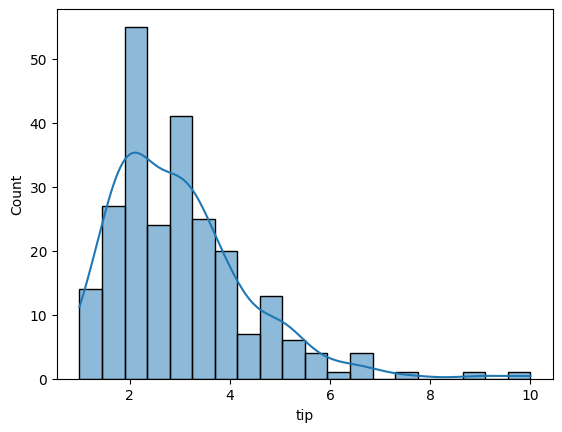

In [2]:
sns.histplot(tips_df['tip'], kde=True, bins=20)

# kde= Kernel Density estimation
# kde non è strattamente necessaria

<class 'pandas.core.series.Series'>


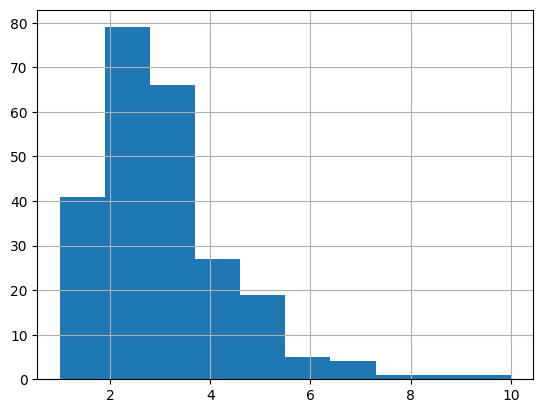

In [3]:
#metodo alternativo
tips_df['tip'].hist()
print(type(tips_df['tip']))

In [4]:
mu = tips_df['tip'].mean() #media delle tips
print('Mean:', mu)

sd = tips_df['tip'].std() #deviazione standard delle tips
print('Standard Deviation:', sd)

skewness = 'right' #asimmetria a destra in questo caso
print('Skewness:', skewness)

Mean: 2.99827868852459
Standard Deviation: 1.3836381890011822
Skewness: right


In [5]:
tips_df.tip.describe() #statistics summary

count    244.000000
mean       2.998279
std        1.383638
min        1.000000
25%        2.000000
50%        2.900000
75%        3.562500
max       10.000000
Name: tip, dtype: float64

<Axes: ylabel='Count'>

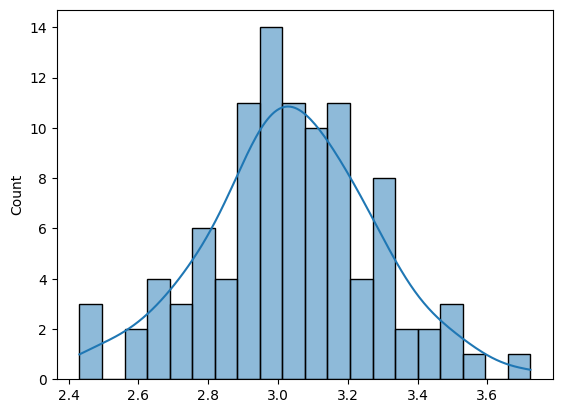

In [6]:
n = 30 #CLT applies mostly with n >= 30, sample size, controls the random noise
N = 100 #how many times we sample, controls the random noise 

means = [tips_df.tip.sample(n, replace=True).mean() for i in range(N)]

sns.histplot(means, bins=20, kde=True)


In [7]:
from scipy.stats import skew

index_df = ['mean', 'stdev', 'skewness']

theory = [mu, sd/np.sqrt(n), 0]

real_life = [np.mean(means), np.std(means), skew(means)] 

comparison_df = pd.DataFrame(list(zip(theory, real_life)),
                             columns = ['CLT Theory', 'Real Tips'],
                             index = index_df)

round(comparison_df, 2)

,CLT Theory,Real Tips
mean,3.00,3.04
stdev,0.25,0.24
skewness,0.00,-0.04
